### Detecção de Fraudes em Licitações Públicas com Redes Neurais LSTM

**Objetivo:** Aplicar uma rede neural recorrente LSTM para identificar possíveis fraudes em licitações públicas utilizando um conjunto de dados sintético.

#### 1. Importação das bibliotecas

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

warnings.filterwarnings("ignore")

#### 2. Criação do Dataset Sintético

In [2]:
np.random.seed(42)

n_samples = 5000

dates = pd.date_range(
    start='2020-01-01',
    periods=n_samples,
    freq='D'
)

orgaos = [
    'Secretaria de Educacao',
    'Secretaria de Saude',
    'Ministerio do Meio Ambiente',
    'Prefeitura de Sao Paulo',
    'Governo do Estado RJ'
]

modalidades = [
    'Pregao',
    'Concorrencia',
    'Convite',
    'Tomada de Precos',
    'Leilao'
]

data = {

    'data': dates,

    'orgao':
    np.random.choice(orgaos,n_samples),

    'modalidade':
    np.random.choice(modalidades,n_samples),

    'valor_estimado':
    np.random.lognormal(12,1.5,n_samples),

    'valor_homologado':
    np.random.lognormal(12,1.5,n_samples),

    'numero_participantes':
    np.random.poisson(5,n_samples),

    'tempo_licitacao_dias':
    np.random.exponential(30,n_samples),

    'numero_aditivos':
    np.random.poisson(1,n_samples),

    'indice_concentracao':
    np.random.beta(2,5,n_samples)

}

df = pd.DataFrame(data)

In [3]:
score_fraud = (

    (df['numero_participantes']<2).astype(int)+

    (df['valor_homologado']>
     df['valor_estimado']*1.5).astype(int)+

    (df['numero_aditivos']>3).astype(int)+

    (df['indice_concentracao']>0.7).astype(int)+

    (df['tempo_licitacao_dias']<5).astype(int)

)

df['fraude']=(score_fraud>=3).astype(int)

print(df.shape)

print(df['fraude'].value_counts())

df.head()

(5000, 10)
fraude
0    4986
1      14
Name: count, dtype: int64


,data,orgao,modalidade,valor_estimado,valor_homologado,numero_participantes,tempo_licitacao_dias,numero_aditivos,indice_concentracao,fraude
0,2020-01-01,Prefeitura de Sao Paulo,Concorrencia,5.093510e+04,271533.269119,2,34.117988,0,0.089312,0
1,2020-01-02,Governo do Estado RJ,Leilao,9.117566e+04,264022.444321,8,32.949261,1,0.111364,0
2,2020-01-03,Ministerio do Meio Ambiente,Tomada de Precos,5.884780e+06,26607.034025,6,7.376361,2,0.324302,0
3,2020-01-04,Governo do Estado RJ,Tomada de Precos,5.147898e+04,808854.256892,6,21.251091,1,0.244745,0
4,2020-01-05,Governo do Estado RJ,Leilao,1.448336e+05,13307.249023,6,7.003953,0,0.511597,0


#### 3. Pré-processamento dos Dados

In [4]:
categorical_cols=[
    'orgao',
    'modalidade'
]

numerical_cols=[
    'valor_estimado',
    'valor_homologado',
    'numero_participantes',
    'tempo_licitacao_dias',
    'numero_aditivos',
    'indice_concentracao'
]

processed_df=df.copy()

label_encoders={}

for col in categorical_cols:

    le=LabelEncoder()

    processed_df[col]=le.fit_transform(
        processed_df[col]
    )

    label_encoders[col]=le

X=processed_df[
    categorical_cols+numerical_cols
]

y=processed_df['fraude'].values

scaler=StandardScaler()

X_scaled=scaler.fit_transform(X)

print(X_scaled[:5])

[[ 1.16217657e-02 -1.39603000e+00 -3.56508047e-01 -1.60771008e-01
  -1.34636471e+00  1.32087167e-01 -1.01321860e+00 -1.22350644e+00]
 [-1.40566674e+00  1.43862457e-02 -3.24019704e-01 -1.65769135e-01
   1.36225528e+00  9.26505613e-02 -1.61856007e-03 -1.08603752e+00]
 [-6.97022485e-01  1.42480249e+00  4.35346488e+00 -3.23758756e-01
   4.59381950e-01 -7.70261295e-01  1.00998148e+00  2.41417572e-01]
 [-1.40566674e+00  1.42480249e+00 -3.56068946e-01  1.96792722e-01
   4.59381950e-01 -3.02083287e-01 -1.61856007e-03 -2.54539524e-01]
 [-1.40566674e+00  1.43862457e-02 -2.80698778e-01 -3.32609184e-01
   4.59381950e-01 -7.82827546e-01 -1.01321860e+00  1.40901727e+00]]


#### 4. Preparação das Sequências Temporais

In [5]:
def create_sequences(data,labels,window_size=10):
    X_seq=[]
    y_seq=[]

    for i in range(len(data)-window_size):
        X_seq.append(
            data[i:i+window_size]
        )
        y_seq.append(
            labels[i+window_size-1]
        )
    return np.array(X_seq),np.array(y_seq)

df_sorted=processed_df.sort_values('data').reset_index(drop=True)

X_sorted=scaler.fit_transform(df_sorted[categorical_cols+numerical_cols])
y_sorted=df_sorted['fraude'].values

WINDOW_SIZE=10

X_seq,y_seq=create_sequences(
    X_sorted,
    y_sorted,
    WINDOW_SIZE
)

print(X_seq.shape)
print(y_seq.shape)

(4990, 10, 8)
(4990,)


In [6]:
split=int(len(X_seq)*0.8)

X_train=X_seq[:split]
X_test=X_seq[split:]

y_train=y_seq[:split]
y_test=y_seq[split:]

print(X_train.shape)
print(X_test.shape)

(3992, 10, 8)
(998, 10, 8)


#### 5. Construção da Rede LSTM

In [7]:
n_features=X_train.shape[2]

model=Sequential([
    LSTM(
        64,
        return_sequences=True,
        input_shape=(WINDOW_SIZE,n_features)
    ),

    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16,activation='relu'),
    Dense(1,activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 64)         │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,649 (123.63 KB)

 Trainable params: 31,649 (123.63 KB)

 Non-trainable params: 0 (0.00 B)

#### 6. Treinamento da Rede Neural

In [8]:
early_stop=EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history=model.fit(
    X_train,
    y_train,

    epochs=30,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9715 - loss: 0.1789 - val_accuracy: 0.9975 - val_loss: 0.0175
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9972 - loss: 0.0202 - val_accuracy: 0.9975 - val_loss: 0.0175
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9972 - loss: 0.0192 - val_accuracy: 0.9975 - val_loss: 0.0175
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9972 - loss: 0.0205 - val_accuracy: 0.9975 - val_loss: 0.0177
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9972 - loss: 0.0204 - val_accuracy: 0.9975 - val_loss: 0.0175
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9972 - loss: 0.0198 - val_accuracy: 0.9975 - val_loss: 0.0180
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9972 - loss: 0.0192 - val_accuracy: 0.9975 - val_loss: 0.0178
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9972 - loss: 0.0195 - val_accuracy: 

#### 7. Avaliação do Modelo

In [9]:
y_pred_prob=model.predict(X_test)
y_pred=(y_pred_prob>0.5).astype(int)

cm=confusion_matrix(
    y_test,
    y_pred
)

print(cm)
print()

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            'Nao Fraude',
            'Fraude'
        ]
    )
)

print(
    accuracy_score(
        y_test,
        y_pred
    )
)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
[[995   0]
 [  3   0]]

              precision    recall  f1-score   support

  Nao Fraude       1.00      1.00      1.00       995
      Fraude       0.00      0.00      0.00         3

    accuracy                           1.00       998
   macro avg       0.50      0.50      0.50       998
weighted avg       0.99      1.00      1.00       998

0.996993987975952


#### 8. Curvas de Treinamento

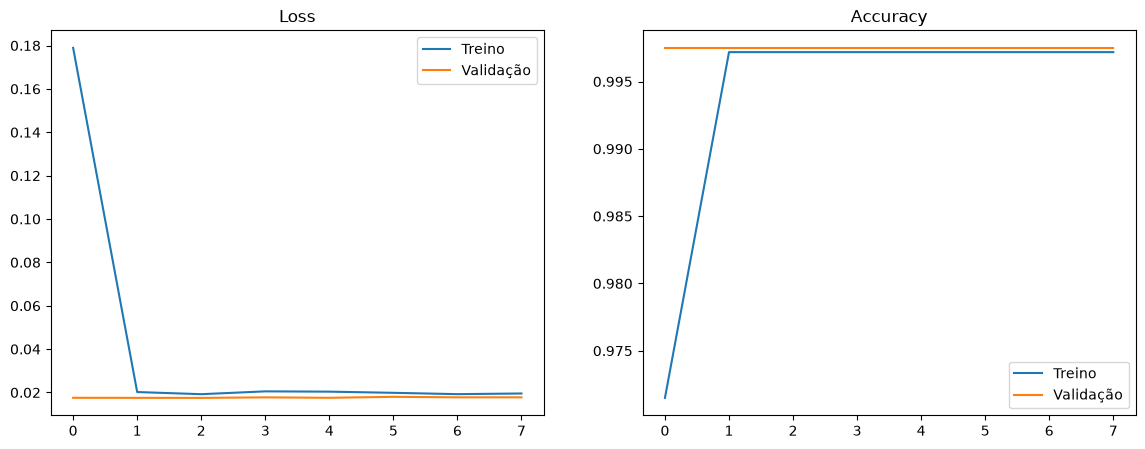

In [10]:
fig,axes=plt.subplots(1,2,figsize=(14,5))

axes[0].plot(history.history['loss'])
axes[0].plot(history.history['val_loss'])
axes[0].set_title('Loss')
axes[0].legend(['Treino','Validação'])

axes[1].plot(history.history['accuracy'])
axes[1].plot(history.history['val_accuracy'])
axes[1].set_title('Accuracy')
axes[1].legend(['Treino','Validação'])

plt.show()

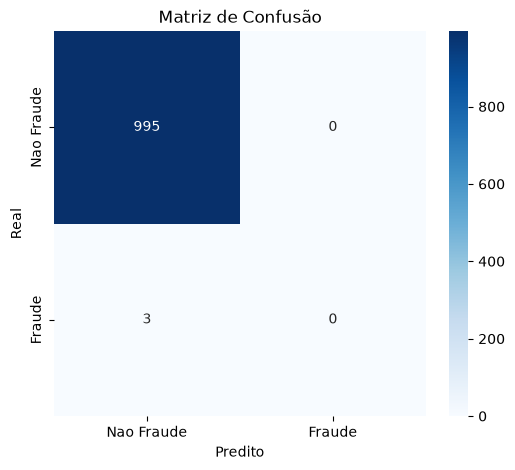

In [11]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Nao Fraude','Fraude'],
    yticklabels=['Nao Fraude','Fraude']
)

plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão")

plt.show()

#### Conclusão

A LSTM apresentou alta acurácia (99,7%) e rápida convergência durante o treinamento. No entanto, devido ao forte desbalanceamento dos dados (apenas 14 fraudes em 5.000 registros), o modelo classificou todos os casos como "Não Fraude", não identificando nenhuma fraude no conjunto de teste.

Assim, conclui-se que, apesar da alta acurácia, o modelo não foi eficaz na detecção de fraudes, evidenciando a necessidade de técnicas de balanceamento de classes e ajustes no treinamento para melhorar o desempenho da classe minoritária.